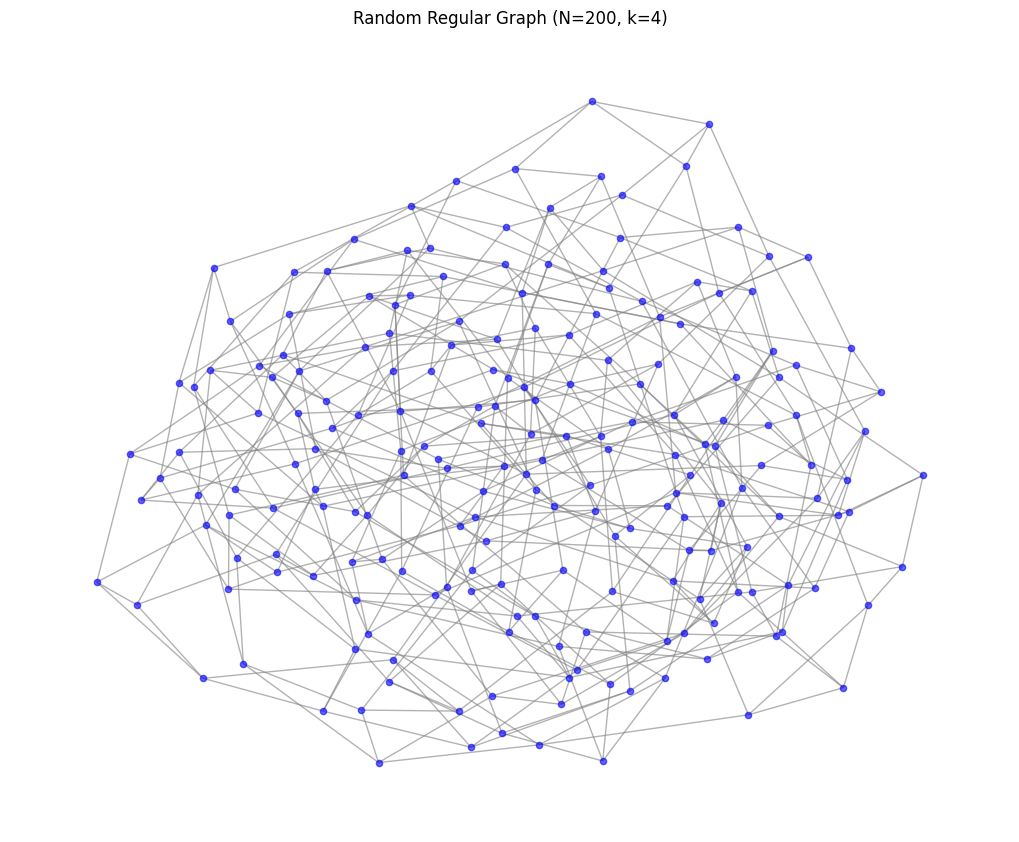

In [1]:
import networkx as nx
import matplotlib.pyplot as plt

# Generate a Random Regular Graph: 200 nodes, each with degree 4
N = 200
k = 4
nx_g = nx.random_regular_graph(k, N)

# Visualize
plt.figure(figsize=(10, 8))
nx.draw(nx_g, node_size=20, node_color='blue', edge_color='gray', alpha=0.6)
plt.title("Random Regular Graph (N=200, k=4)")
plt.show()

In [2]:
from networkx.algorithms import community

# 1. Greedy Modularity
greedy_comm = community.greedy_modularity_communities(nx_g)
print(f"Greedy Modularity found {len(greedy_comm)} communities.")

# 2. Louvain Method
louvain_comm = community.louvain_communities(nx_g)
print(f"Louvain Method found {len(louvain_comm)} communities.")

Greedy Modularity found 10 communities.
Louvain Method found 11 communities.


When you used modularity optimization, the algorithms fell victim to the resolution limit and the nature of random fluctuations. In any random graph, some areas will have slightly more edges than others purely by chance. Modularity optimization is "greedy"—it mistakes these random fluctuations for meaningful communities and partitions the network to maximize the $Q$ score.

The `graph-tool` Bayesian inference code likely resulted in **1 block**. This is because Bayesian inference (specifically using the Stochastic Block Model) asks: "Is this partition more likely than a single random block?". Since the network was generated as a single random block, the Bayesian method correctly identifies that there is **no statistically significant community structure**.

**Does the partition reflect the underlying model?**
No. The partitions found by Louvain and Greedy Modularity do not reflect the underlying model (which is a single, uniform random component). They provide an "optimal" mathematical answer to a formula, but that answer is biologically and socially meaningless in the context of this random school of fish.

In [3]:
import graph_tool.all as gt

# convert networkx graph (nx_g) to graph-tool graph (gt_g)
gt_g = gt.Graph(nx.adjacency_matrix(nx_g), directed = False)
gt_g_state = gt.BlockState(gt_g)
print("State is initialized with: {:.0f} block ".format(gt_g_state.get_nonempty_B()))

# Next we call the MCMC function:
dS, nattempts, nmoves = gt_g_state.multiflip_mcmc_sweep(niter=1000)
print("Change in description length:", dS)
print("Number of moves attempted:", nattempts)
print("Number of accepted vertex moves:", nmoves)

print('\nUsing Baysian inference we get {:.0f} block(s) instead'.format(g_gt_state.get_nonempty_B()))
print('and the modularity index is {:.0f}'.format(gt.modularity(g_gt, g_gt_state.get_blocks())))

ModuleNotFoundError: No module named 'graph_tool'